# Importing libraries

In [140]:
#Import libraries

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder, MinMaxScaler, KBinsDiscretizer
from sklearn.feature_selection import chi2, mutual_info_classif
from scipy.stats import ttest_ind
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

 # Loading the dataset

In [90]:
# Note: the path is absolute and needs to be updated depending on the machine.
df_train = pd.read_csv(r'C:\Users\Usuario\Desktop\Data_Analyst\python\Esame_finale_data_science\train.csv')

# First look at the dataset

 Before doing anything else, it's always a good idea to understand what we're working with.

 We check the shape, column names, a few sample rows, and descriptive statistics (mean, std, min/max, etc.).
 We also look for missing values: "Arrival Delay in Minutes" has 310 NaNs, roughly 0.3% of the dataset — manageable.

In [91]:
print(f'Shape: {df_train.shape}')
print('-'*100)
print(f'Columns names : {df_train.columns}')
print('-'*100)
display(df_train)
print('-'*100)
display(df_train.describe().round(2))
print('-'*100)
print(f'Missing Values: \n{df_train.isna().sum()}')

Shape: (103904, 25)
----------------------------------------------------------------------------------------------------
Columns names : Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')
----------------------------------------------------------------------------------------------------


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


----------------------------------------------------------------------------------------------------


,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103594.00
mean,51951.50,64924.21,39.38,1189.45,2.73,3.06,2.76,2.98,3.20,3.25,3.44,3.36,3.38,3.35,3.63,3.30,3.64,3.29,14.82,15.18
std,29994.65,37463.81,15.11,997.15,1.33,1.53,1.40,1.28,1.33,1.35,1.32,1.33,1.29,1.32,1.18,1.27,1.18,1.31,38.23,38.70
min,0.00,1.00,7.00,31.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,25975.75,32533.75,27.00,414.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,3.00,3.00,3.00,2.00,0.00,0.00
50%,51951.50,64856.50,40.00,843.00,3.00,3.00,3.00,3.00,3.00,3.00,4.00,4.00,4.00,4.00,4.00,3.00,4.00,3.00,0.00,0.00
75%,77927.25,97368.25,51.00,1743.00,4.00,4.00,4.00,4.00,4.00,4.00,5.00,4.00,4.00,4.00,5.00,4.00,5.00,4.00,12.00,13.00
max,103903.00,129880.00,85.00,4983.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,1592.00,1584.00


----------------------------------------------------------------------------------------------------
Missing Values: 
Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness          

# Target distribution

In [92]:
# We check how the target variable is distributed. This matters later when evaluating models.
# Our target is a binary category, model will be a binary classification
print(f'\n Target: {df_train['satisfaction'].value_counts()}') 


 Target: satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64


# Dropping useless column

Actions to take:
- Drop the "Unnamed: 0" column: it's a duplicate index automatically generated
  when the CSV was saved, it carries no useful information.

In [93]:
df_train.drop(columns='Unnamed: 0', inplace=True)

# Encoding the target

In [94]:
# sklearn models work with numeric values, so we need to convert the target variable from text to integer.
# We map: 0 = neutral or dissatisfied, 1 = satisfied.
# We do this before the EDA so we can use the target in plots as well.
df_train['satisfaction'] = df_train['satisfaction'].map({
    'neutral or dissatisfied': 0,
    'satisfied': 1
})

# EDA - Exploratory Data Analysis


In [95]:
# We compute the average satisfaction rate for each categorical variable.
for col in ['Gender', 'Class', 'Customer Type','Type of Travel']:
    print(f'\nSatisfaction rate per: {col}')
    print(df_train.groupby(col)['satisfaction'].mean().round(2))


Satisfaction rate per: Gender
Gender
Female    0.43
Male      0.44
Name: satisfaction, dtype: float64

Satisfaction rate per: Class
Class
Business    0.69
Eco         0.19
Eco Plus    0.25
Name: satisfaction, dtype: float64

Satisfaction rate per: Customer Type
Customer Type
Loyal Customer       0.48
disloyal Customer    0.24
Name: satisfaction, dtype: float64

Satisfaction rate per: Type of Travel
Type of Travel
Business travel    0.58
Personal Travel    0.10
Name: satisfaction, dtype: float64


### Even at this stage, some differences stand out clearly:

Business class passengers are much more satisfied than Economy ones.

The type of travel (business vs personal) also seems to play a significant role.

# EDA visualizations

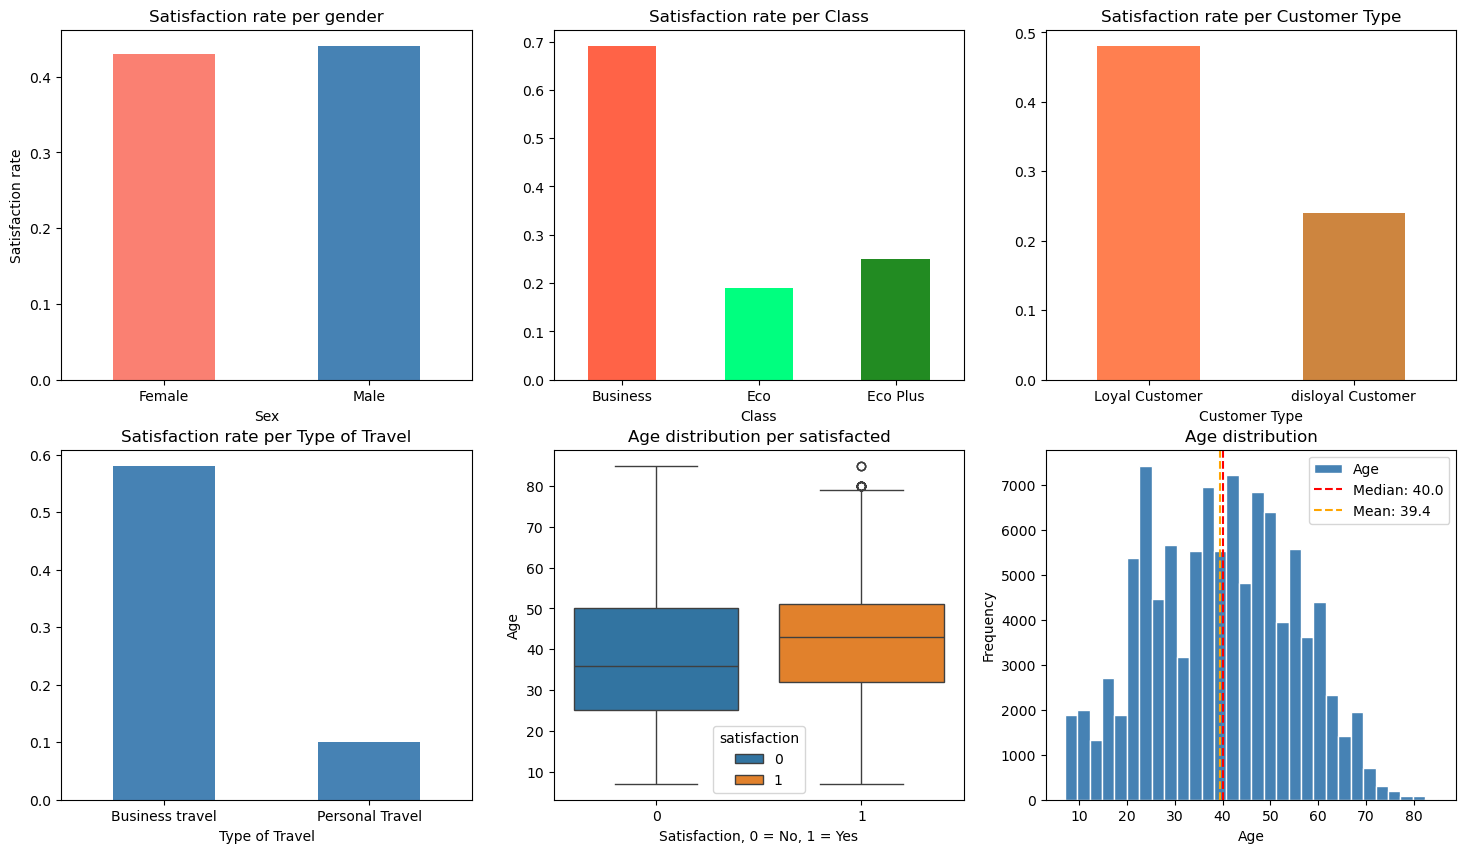

In [96]:
#CHARTS

fig, axes = plt.subplots(2, 3, figsize=(18,10))

df_train.groupby('Gender')['satisfaction'].mean().round(2).plot(kind='bar', ax=axes[0, 0], color=['salmon','steelblue'])
axes[0,0].set_title('Satisfaction rate per gender')
axes[0,0].set_ylabel('Satisfaction rate')
axes[0,0].set_xlabel('Sex')
axes[0,0].tick_params(axis='x', rotation = 0)

df_train.groupby('Class')['satisfaction'].mean().round(2).plot(kind='bar', ax=axes[0,1], color=['tomato','springgreen','forestgreen'])
axes[0,1].set_title('Satisfaction rate per Class')
axes[0,1].tick_params(axis='x', rotation = 0)

df_train.groupby('Customer Type')['satisfaction'].mean().round(2).plot(kind='bar', ax=axes[0,2], color=['coral','peru'])
axes[0,2].set_title('Satisfaction rate per Customer Type')
axes[0,2].tick_params(axis='x', rotation = 0)

sns.boxplot(data=df_train, x='satisfaction',y='Age', ax=axes[1,1], hue=df_train['satisfaction'])
axes[1,1].set_title('Age distribution per satisfacted')
axes[1,1].set_xlabel('Satisfaction, 0 = No, 1 = Yes')

df_train.groupby('Type of Travel')['satisfaction'].mean().round(2).plot(kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Satisfaction rate per Type of Travel')
axes[1,0].tick_params(axis='x', rotation = 0)

df_train['Age'].plot(kind='hist', bins=30, ax=axes[1,2], color='steelblue', edgecolor='white')
axes[1,2].axvline(df_train['Age'].median(), color='red', linestyle='--', label=f"Median: {df_train['Age'].median():.1f}")
axes[1,2].axvline(df_train['Age'].mean(), color='orange', linestyle='--', label=f"Mean: {df_train['Age'].mean():.1f}")
axes[1,2].set_title('Age distribution')
axes[1,2].set_xlabel('Age')
axes[1,2].legend()

We visualize the patterns found above in a more intuitive way.
Bar charts show the satisfaction rate for each category.
- The boxplot on age suggests that satisfied passengers tend to be slightly older.
- The age histogram shows a fairly balanced distribution, with mean and median both around 39–40 years old.

In [ ]:
# We group by the target variable and compute the mean of each service rating for satisfied (1) and dissatisfied (0) passengers.
# This lets us see which services have the largest gap between the two groups — those are likely the strongest levers for improving overall satisfaction.
rating_cols = [ 
        'Flight Distance', 'Inflight wifi service',
        'Departure/Arrival time convenient', 'Ease of Online booking',
        'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
        'Inflight entertainment', 'On-board service', 'Leg room service',
        'Baggage handling', 'Checkin service', 'Inflight service',
        'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
        ]

df_train.groupby('satisfaction')[rating_cols].mean().round(2)

,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
satisfaction,,,,,,,,,,,,,,,,,
0,928.92,2.40,3.13,2.55,2.98,2.96,2.66,3.04,2.89,3.02,2.99,3.38,3.04,3.39,2.94,16.50,17.13
1,1530.14,3.16,2.97,3.03,2.98,3.52,4.03,3.97,3.96,3.86,3.82,3.97,3.65,3.97,3.74,12.61,12.63


Services with the most evident gap:
Online boarding (2.66 vs 4.03), Seat comfort (3.04 vs 3.97), and Inflight entertainment (2.89 vs 3.96) show the largest differences between the two groups — roughly 1 point on a 5-point scale.

Flight Distance:
Satisfied passengers fly, on average, much longer distances (1530 vs 929 km) — likely because long-haul flights are predominantly Business class.

# Splitting features and target

In [97]:
#Split features (X) and y(target)

X = df_train.drop(columns='satisfaction')
y = df_train['satisfaction']

# Train / Validation / Test split

In [98]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(X.shape)
print(y.shape)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(X_val.shape, y_val.shape)


(103904, 23)
(103904,)
(72732, 23) (15586, 23) (72732,) (15586,)
(15586, 23) (15586,)


 # Preprocessing pipeline + first model (Logistic Regression)

In [ ]:
#define numerical and categorical columns
num_col = [
        'Age', 
        'Flight Distance', 'Inflight wifi service',
        'Departure/Arrival time convenient', 'Ease of Online booking',
        'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
        'Inflight entertainment', 'On-board service', 'Leg room service',
        'Baggage handling', 'Checkin service', 'Inflight service',
        'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
        ]

cat_col = ['Gender', 'Customer Type', 'Type of Travel','Class']

# For numerical features: SimpleImputer with strategy="median": fills missing values with the median(more robust than the mean when outliers are present)
# - StandardScaler: normalizes values to z-scores, required for Logistic Regression and useful for many other algorithms
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For categorical features:
# - OneHotEncoder: converts each category into a binary (0/1) column drop='first' removes one redundant category to avoid multicollinearity
cat_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

col_transform = ColumnTransformer(transformers=[
    ('num',num_pipeline, num_col),
    ('cat',cat_pipeline,cat_col)
])

# As a first model we use Logistic Regression as a simple baseline.
model = LogisticRegression(max_iter=1000)

# We wrap everything in a sklearn Pipeline that chains preprocessing and model together.
# This prevents data leakage: the scaler fits only on the training fold, never on validation or test data.
clf = Pipeline(steps=[
    ('col_transform', col_transform),
    ('model', model)

])

clf.fit(X_train, y_train)
y_val_predict = clf.predict(X_val)
print(clf.score(X_val, y_val))


0.8771974849223663


#  Evaluation metrics, correlation matrix, class balance

## We evaluate the baseline model using several metrics:

- Accuracy: percentage of correct predictions over total

- Precision: of all the times the model predicted "satisfied"

- Recall: of all the passengers who were truly satisfied

- F1-score: harmonic mean of precision and recall

- Confusion matrix: shows true positives, false positives


Classification report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      8825
           1       0.87      0.84      0.86      6761

    accuracy                           0.88     15586
   macro avg       0.88      0.87      0.87     15586
weighted avg       0.88      0.88      0.88     15586

--------------------------------------------------------------------------------
Confusion matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x0000027236B03290>


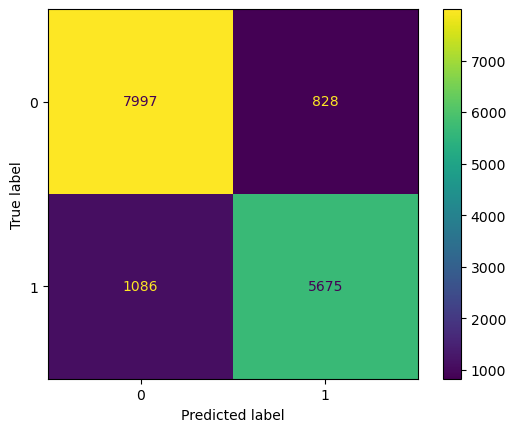

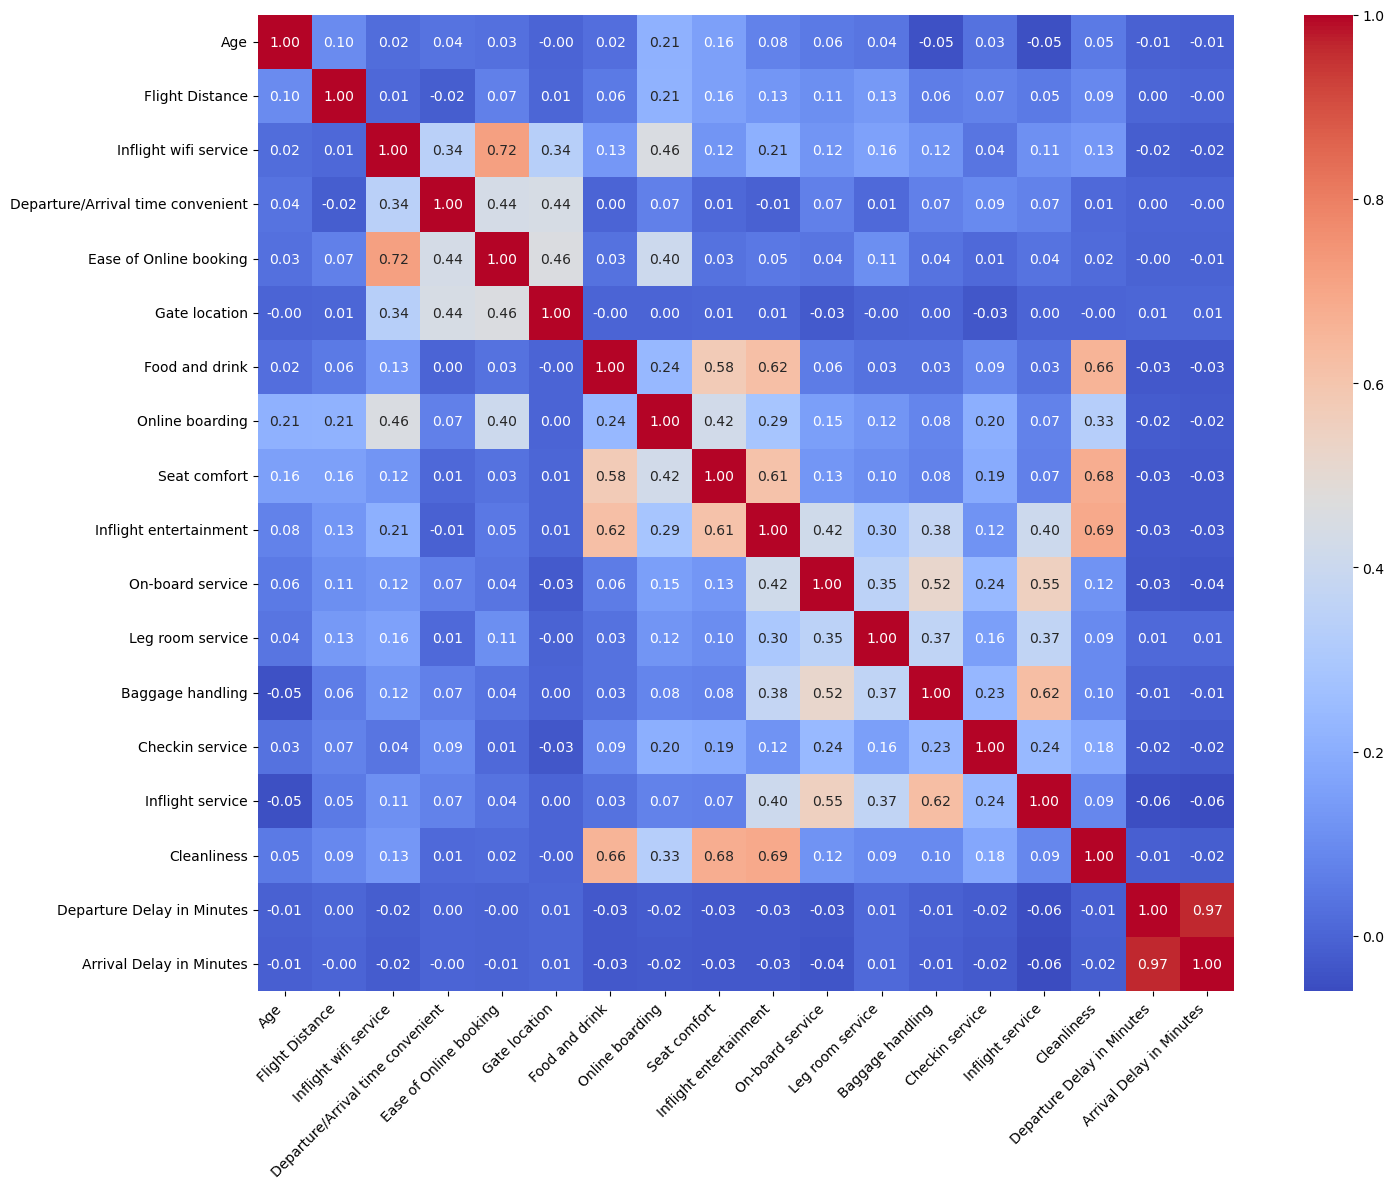

--------------------------------------------------------------------------------
satisfaction
0    0.566667
1    0.433333
Name: proportion, dtype: float64


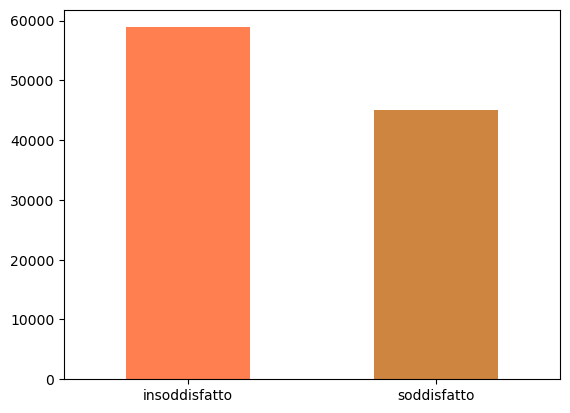

In [101]:
#METRICS

#classification report
cr = classification_report(y_val, y_val_predict)
print(f'Classification report:\n{cr}')
print('--'*40)

#Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = ConfusionMatrixDisplay.from_predictions(y_val, y_val_predict)
print(f'Confusion matrix: {cm}')

#Correlation matrix
number_col = X_train.select_dtypes(include='number')
number_col.drop(columns='id', inplace=True)
corr_matrix = number_col.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print('--'*40)

#bilanciamento target
mapping = {0 :'insoddisfatto', 1: 'soddisfatto'}
print(y.value_counts(normalize=True))
y.map(mapping).value_counts().plot(kind="bar", color=['coral','peru'])
plt.xlabel('')
plt.xticks(rotation = 0)
plt.show()


- The correlation matrix reveals that "Departure Delay in Minutes" and "Arrival Delay in Minutes" have a correlation of ~0.96 
they carry almost identical information. One of them needs to go.

- The class balance plot confirms what we saw earlier: 57% dissatisfied vs 43% satisfied — slightly imbalanced but not critical.

# Dropping redundant columns and updating the pipeline

We drop "Arrival Delay in Minutes" because the correlation matrix shows it's
nearly identical to "Departure Delay in Minutes" (correlation ~0.96).
Keeping both would introduce multicollinearity without adding new information.
We also remove the "id" column since it's just a unique passenger identifier
with no predictive value.

In [ ]:
to_drop = ['id', 'Arrival Delay in Minutes']

X_train_model = X_train.drop(columns=to_drop, errors='ignore')
X_val_model = X_val.drop(columns=to_drop, errors='ignore')
X_test_model = X_test.drop(columns=to_drop, errors='ignore')

num_col = [c for c in num_col if c not in to_drop]
cat_col = [c for c in cat_col if c not in to_drop]

#The pipeline needs to be rebuilt from scratch after changing the feature set — otherwise sklearn would try to apply the old transformers to the new columns.
cl = ColumnTransformer([
    ('num', num_pipeline, num_col),
    ('cat', cat_pipeline, cat_col)
])

clf = Pipeline([
    ('preprocessor', cl),
    ('model', model)
])

clf.fit(X_train_model, y_train)
y_val_predict_w = clf.predict(X_val)

 # Metrics after cleaning
 We recalculate the metrics after removing the redundant columns.
 
The Logistic Regression accuracy stays around ~88%, which confirms that the dropped column wasn't adding meaningful new information.

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      8825
           1       0.87      0.84      0.86      6761

    accuracy                           0.88     15586
   macro avg       0.88      0.87      0.87     15586
weighted avg       0.88      0.88      0.88     15586

--------------------------------------------------------------------------------
Confusion matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x0000027235524710>


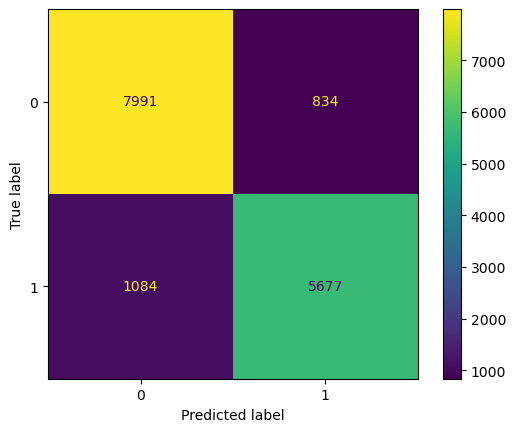

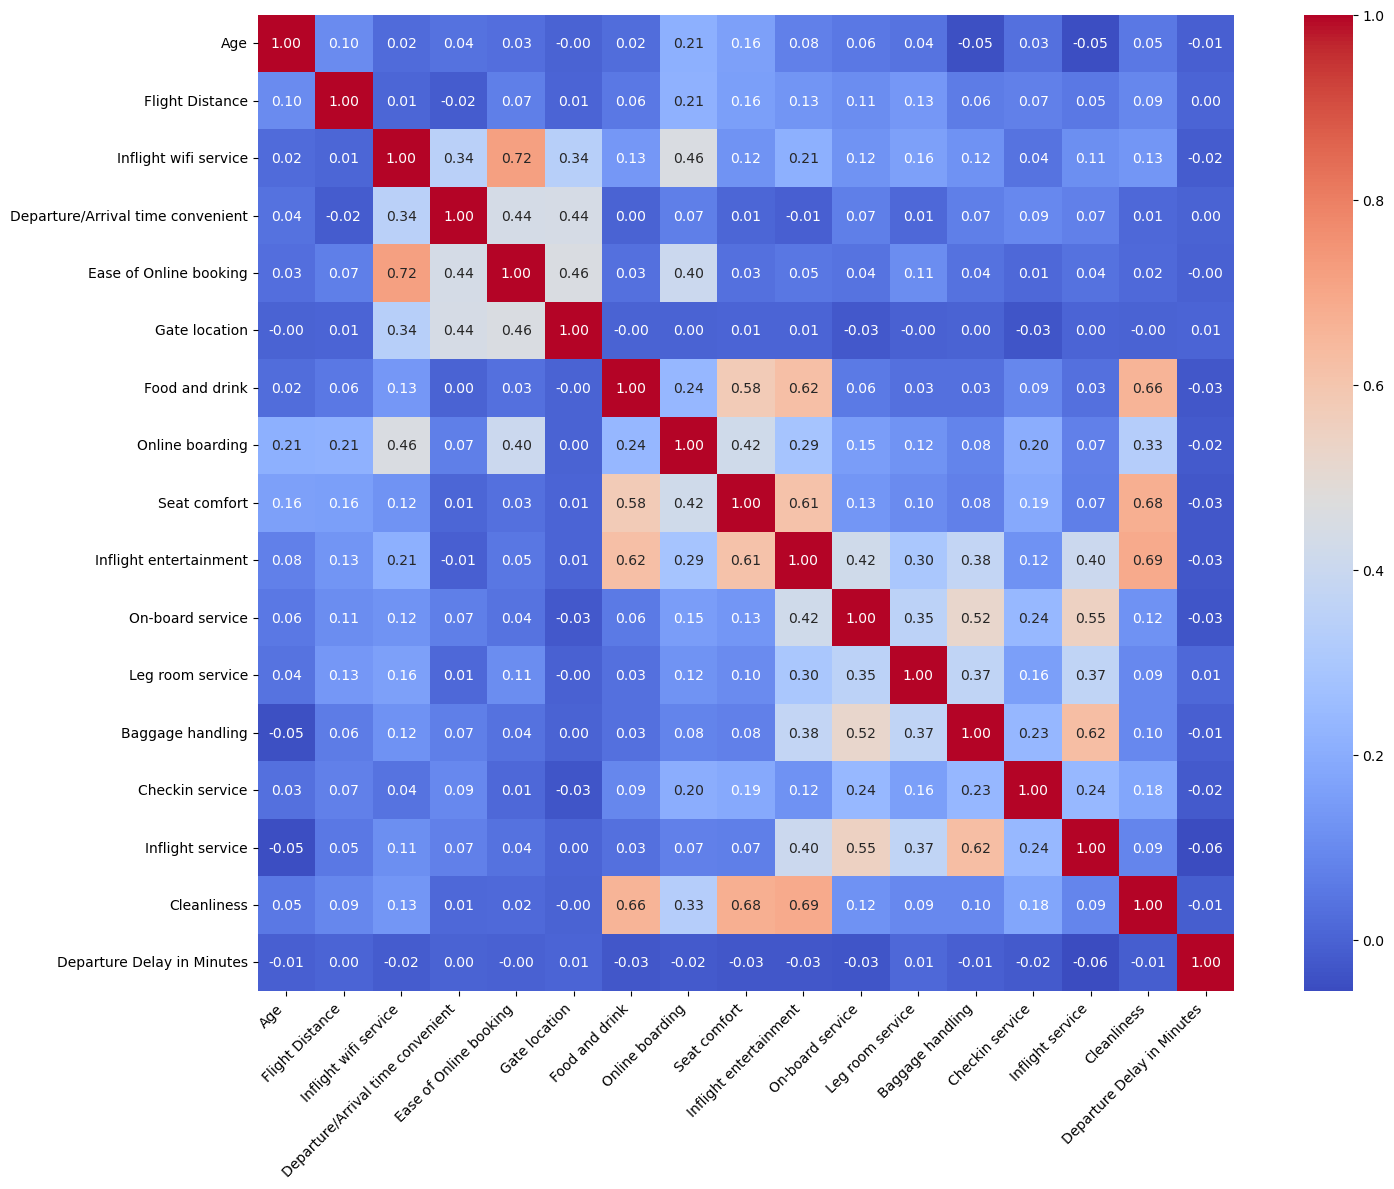

--------------------------------------------------------------------------------


In [ ]:
#METRICS

#classification report
cr = classification_report(y_val, y_val_predict_w)
print(f'Classification report:\n{cr}')
print('--'*40)

#Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = ConfusionMatrixDisplay.from_predictions(y_val, y_val_predict_w)
print(f'Confusion matrix: {cm}')

#correlation matrix
number_col_m = X_train_model.select_dtypes(include='number')
corr_matrix = number_col_m.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print('--'*40)


# Feature selection: Chi-Square test

To identify the most relevant features we try three different approaches and then compare the results.

## CHI-SQUARE TEST:
Measures the statistical dependency between each feature and the target.

A high chi2_score and a low p-value (< 0.05) indicate that the feature is significantly associated with the target variable.
Important: chi-square requires non-negative values, so for columns with negative minimums we shift them by subtracting the minimum.


In [ ]:
target_col = "satisfaction"
df_fs = X_train_model.copy()
df_fs[target_col] = y_train.values if hasattr(y_train, "values") else y_train

X_fs = df_fs.drop(columns=[target_col])
y_fs = df_fs[target_col]  # already numeric (0/1)

cat_cols = X_fs.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_fs.select_dtypes(include=[np.number]).columns.tolist()

X_chi = X_fs.copy()

# Encode categorical columns as integer codes
for col in cat_cols:
    X_chi[col] = X_chi[col].astype("category").cat.codes

# Chi-square requires non-negative values — scale everything to [0, 1]
scaler = MinMaxScaler()
X_chi[num_cols] = scaler.fit_transform(X_chi[num_cols])

# For continuous features, discretize into bins before applying chi-square
continuous_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes']
kbd = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
X_chi[continuous_cols] = kbd.fit_transform(X_chi[continuous_cols])

X_chi = X_chi.fillna(0)

chi_scores, chi_p = chi2(X_chi, y_fs)
chi2_df = pd.DataFrame({
    "feature": X_chi.columns,
    "chi2_score": chi_scores,
    "p_value": chi_p
}).sort_values("chi2_score", ascending=False)

print(chi2_df.head(20))

                              feature    chi2_score        p_value
3                      Type of Travel  10111.172205   0.000000e+00
4                               Class   9486.801686   0.000000e+00
5                     Flight Distance   8790.540525   0.000000e+00
2                                 Age   3080.017145   0.000000e+00
1                       Customer Type   2103.635052   0.000000e+00
11                    Online boarding   2077.523807   0.000000e+00
13             Inflight entertainment   1209.713256  4.724379e-265
12                       Seat comfort    905.636643  5.840991e-199
20         Departure Delay in Minutes    765.604438  1.623608e-168
6               Inflight wifi service    751.378707  2.011969e-165
14                   On-board service    735.311900  6.268524e-162
15                   Leg room service    728.638821  1.770844e-160
19                        Cleanliness    706.482529  1.164246e-155
16                   Baggage handling    586.299664  1.598778e

c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


# Feature selection: Mutual Information

Measures how much information a feature provides about the target. Unlike chi-square, it captures non-linear relationships as well.
A higher value means the feature is more informative.

Comparing these results with chi-square helps us check whether the selected features are consistent across methods.

In [130]:
#MUTUAL INFORMATION
X_mi = X_fs.copy()
for col in cat_cols:
    X_mi[col] = X_mi[col].astype("category").cat.codes

X_mi = X_mi.fillna(0)

mi_scores = mutual_info_classif(X_mi, y_fs, random_state=42)
mi_df = pd.DataFrame({
    "feature": X_mi.columns,
    "mutual_info": mi_scores
}).sort_values("mutual_info", ascending=False)

print(mi_df.head(20))



                       feature  mutual_info
11             Online boarding     0.215312
6        Inflight wifi service     0.164560
4                        Class     0.136037
3               Type of Travel     0.118415
13      Inflight entertainment     0.093053
12                Seat comfort     0.082125
15            Leg room service     0.065100
14            On-board service     0.062198
5              Flight Distance     0.060427
8       Ease of Online booking     0.055510
19                 Cleanliness     0.051704
2                          Age     0.043153
16            Baggage handling     0.042440
18            Inflight service     0.040872
17             Checkin service     0.031931
10              Food and drink     0.029280
1                Customer Type     0.021327
9                Gate location     0.014713
0                       Gender     0.004547
20  Departure Delay in Minutes     0.003206


# Feature selection: T-test

Tests whether the mean of a numerical feature is significantly different between satisfied and dissatisfied passengers.

A very low p-value (< 0.05, ideally < 0.001) means the feature discriminates well between the two classes.

The features with the lowest p-values are the ones we'll use in "Road 2".



In [ ]:
# 3) T-TEST
print("\n=== T-TEST ===")

ttest_results = []

for col in num_cols:
    group0 = X_fs.loc[y_fs == 0, col].dropna()
    group1 = X_fs.loc[y_fs == 1, col].dropna()

    if len(group0) > 1 and len(group1) > 1:
        stat, p = ttest_ind(group0, group1, equal_var=False)
        ttest_results.append({
            "feature": col,
            "t_stat": stat,
            "p_value": p,
            "mean_class_0": group0.mean(),
            "mean_class_1": group1.mean()
        })

ttest_df = pd.DataFrame(ttest_results).sort_values("p_value")
print(ttest_df.head(20))


=== T-TEST ===
                              feature      t_stat       p_value  mean_class_0  \
0                                 Age  -39.170590  0.000000e+00     37.492910   
1                     Flight Distance  -80.682224  0.000000e+00    929.334527   
2               Inflight wifi service  -74.657600  0.000000e+00      2.400082   
4              Ease of Online booking  -45.206583  0.000000e+00      2.546583   
7                     Online boarding -156.530003  0.000000e+00      2.650058   
6                      Food and drink  -59.104276  0.000000e+00      2.956151   
9              Inflight entertainment -119.780617  0.000000e+00      2.892556   
8                        Seat comfort -102.683544  0.000000e+00      3.032064   
12                   Baggage handling  -69.168501  0.000000e+00      3.374577   
13                    Checkin service  -66.089178  0.000000e+00      3.044454   
10                   On-board service  -93.099048  0.000000e+00      3.021852   
11          

### Results show that the 4 most discriminating features are:
Age, Flight Distance, Inflight wifi service, Ease of Online booking.

# Importantest Features

Features that appear in at least 2 out of 3 methods


In [ ]:
top_chi2 = set(chi2_df.head(5)['feature'])
top_mi   = set(mi_df.head(5)['feature'])
top_ttest = set(ttest_df.head(5)['feature'])

# Features that appear in at least 2 out of 3 methods
from collections import Counter
all_top = list(top_chi2) + list(top_mi) + list(top_ttest)
Counter(all_top).most_common()

[('Class', 2),
 ('Age', 2),
 ('Type of Travel', 2),
 ('Flight Distance', 2),
 ('Online boarding', 2),
 ('Inflight wifi service', 2),
 ('Customer Type', 1),
 ('Inflight entertainment', 1),
 ('Ease of Online booking', 1)]

These features — 'Class', 'Age', 'Type of Travel', 'Flight Distance', 'Online boarding', 'Inflight wifi service' — are consistently ranked among the top in multiple tests, indicating their high importance and strongest predictors

# Road 1 begins:
###  All available features

We now follow the first approach: train the models using all features
(except "id" and "Arrival Delay in Minutes" already removed).
This is the most complete configuration — we'll see later whether using fewer features leads to comparable or better results.

 # Preprocessor + train_and_evaluate()

In [ ]:
to_drop = ['id', 'Arrival Delay in Minutes']

X_train_model = X_train.drop(columns=to_drop, errors='ignore')
X_val_model = X_val.drop(columns=to_drop, errors='ignore')
X_test_model = X_test.drop(columns=to_drop, errors='ignore')

num_cols = X_train_model.select_dtypes(include='number').columns.tolist()
cat_cols = X_train_model.select_dtypes(exclude='number').columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

#We define a helper function train_and_evaluate() to avoid repeating the same boilerplate for every model.
def train_and_evaluate(model, X_tr, y_tr, X_v, y_v, name='model'):
    clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)])

    clf.fit(X_tr, y_tr)
    y_val_pred_full = clf.predict(X_v)

    print(classification_report(y_v, y_val_pred_full))

    cm = ConfusionMatrixDisplay.from_predictions(y_v, y_val_pred_full)
    print(f'Confusion matrix: {cm}')
    return clf, y_val_pred_full, cm


# Spot check on three models

Before committing to any model, we run a quick spot check using Stratified K-Fold Cross Validation (k=5).

The idea is simple: instead of training once on train and evaluating on val, we split the training set into 5 folds and rotate which one is used for evaluation.


In [ ]:
# We use default hyperparameters here — the spot check is not meant to be a full training, just a fast comparison to see which model type looks more promising.
# We'll tune the best ones properly afterwards.
models = {
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

#"Stratified" means each fold preserves the original class proportions.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_train_model, y_train, cv=cv, scoring='accuracy')
    results.append((name, scores.mean(), scores.std()))

 The model with the highest mean accuracy and lowest std is the most stable and promising one to tune further.

In [134]:
results

[('Random Forest',
  np.float64(0.9613650027238572),
  np.float64(0.0010776788196242004)),
 ('AdaBoost',
  np.float64(0.9102046561650171),
  np.float64(0.002303850541323906)),
 ('Gradient Boosting',
  np.float64(0.9412912791359792),
  np.float64(0.0017603403801894795))]

 # Random Forest (full training)
 Based on the spot check, Random Forest is one of the two best performing models.

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      8825
           1       0.97      0.94      0.95      6761

    accuracy                           0.96     15586
   macro avg       0.96      0.96      0.96     15586
weighted avg       0.96      0.96      0.96     15586

Confusion matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x0000027236740D50>


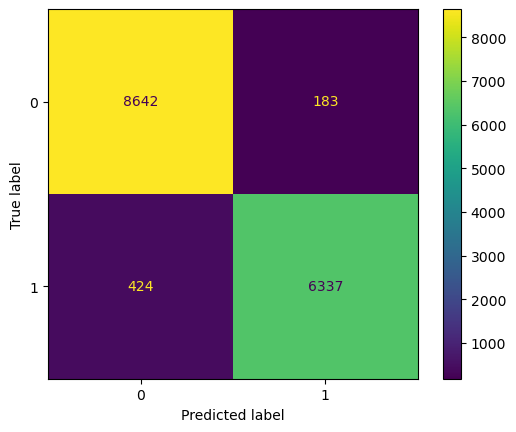

In [141]:
#We now train it properly with more considered hyperparameters
rf = RandomForestClassifier(
    n_estimators=300, # n_estimators=300: 300 trees in the forest — more trees means more stable predictions, at the cost of longer training time
    random_state=42,
    n_jobs=-1,
    class_weight='balanced' #give more weight to the minority class automatically
)

clf_rf, y_val_pred_rf, cm_rf = train_and_evaluate(
    rf, X_train_model, y_train, X_val_model, y_val, name="Random Forest")

# AdaBoost (full training)

 AdaBoost trains trees sequentially: each new tree focuses more on the samples the previous one got wrong

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      8825
           1       0.91      0.89      0.90      6761

    accuracy                           0.91     15586
   macro avg       0.91      0.91      0.91     15586
weighted avg       0.91      0.91      0.91     15586

Confusion matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002723A37C550>


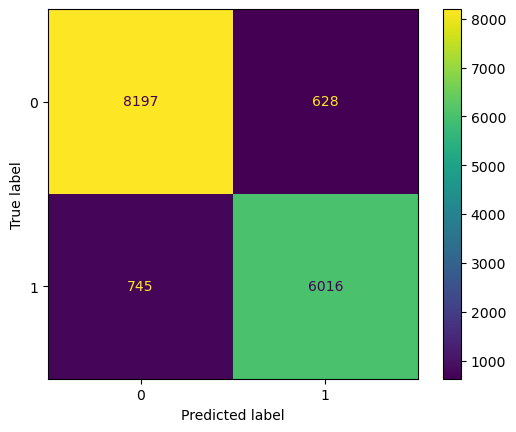

In [ ]:
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42) #the simplest possible tree.
ada =  AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=200,
    learning_rate=0.5, # learning_rate=0.5 controls how much each tree contributes to the final vote
    random_state=42
)
clf_ada, y_val_pred_ada, cm_ada =train_and_evaluate(
    ada, X_train_model, y_train, X_val_model, y_val, name="Adaboost")

# Gradient Boosting (full training)
Gradient Boosting also builds trees sequentially, but instead of reweighting misclassified samples it minimizes a loss function using gradients at each step.

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8825
           1       0.94      0.92      0.93      6761

    accuracy                           0.94     15586
   macro avg       0.94      0.94      0.94     15586
weighted avg       0.94      0.94      0.94     15586

Confusion matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x0000027233F66F50>


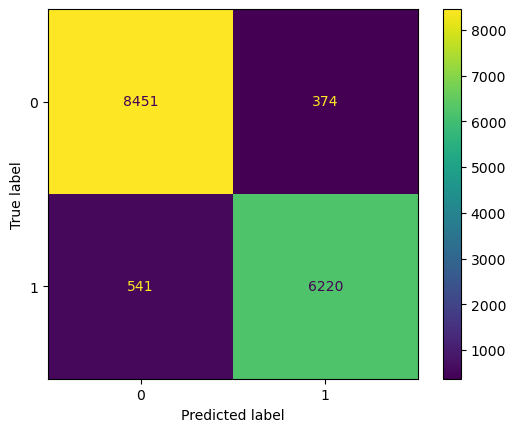

In [ ]:
gb = GradientBoostingClassifier(
    random_state=42,
    n_estimators=200,  # n_estimators=200 with learning_rate=0.1 is a classic combination: many small trees with slow learning tends to generalize well. 
    learning_rate=0.1
    )

clf_gb, y_val_pred_gb, cm_gb = train_and_evaluate(
    gb, X_train_model, y_train, X_val_model, y_val, name='Gradient boost'
)

 # Road 2: 
 ## top 4 features from T-test

In [ ]:
# We now follow Road 2: only the 4 numerical features that the T-test identified as most discriminating (lowest p-values):
selected_cols = [
    'Age',
    'Flight Distance',
    'Inflight wifi service',
    'Ease of Online booking'
]

# The goal is to check whether a leaner model with fewer features can compete with the full one. A simpler model is also easier to interpret and explain to non-technical stakeholders.
X_train_4 = X_train_model[selected_cols].copy()
X_val_4 = X_val_model[selected_cols].copy()
X_test_4 = X_test_model[selected_cols].copy()

# Spot check Road 2

In [ ]:
# Same spot check as Road 1, but applied to the 4-feature subset.
#Note: here we don't use the full preprocessor pipeline since all 4 features are already numerical — the models can take them directly.

results_4 = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_4, y_train, cv=cv, scoring='accuracy')
    results_4.append((name, scores.mean(), scores.std()))

In [138]:
results_4

[('Random Forest',
  np.float64(0.7759857953563493),
  np.float64(0.0014224070948377593)),
 ('Adaboost', np.float64(0.7858027183298699), np.float64(0.00240554724319453)),
 ('Gradient Boosting',
  np.float64(0.8089974434957108),
  np.float64(0.0020387520508296114))]

# Road 2 models with evaluation
Based on the Road 2 spot check, Gradient Boosting performs best on the reduced feature set.

We train all three models anyway for completeness and to compare their metrics side by side.

In [ ]:
#Random forest
rf_4 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_4.fit(X_train_4, y_train)
y_predict_4_rf = rf_4.predict(X_val_4)

#Adaboost
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)
ada_4 =  AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada_4.fit(X_train_4, y_train)
y_predict_4_ada = ada_4.predict(X_val_4)

#Gradientboost
gb_4 = GradientBoostingClassifier(random_state=42, n_estimators=200, learning_rate=0.1)
gb_4.fit(X_train_4, y_train)
y_predict_4_gb = gb_4.predict(X_val_4)

Random Forest metrics using the importantest 4 variables according to T-test : 

classification report:
               precision    recall  f1-score   support

           0       0.79      0.81      0.80     14677
           1       0.75      0.72      0.73     11299

    accuracy                           0.77     25976
   macro avg       0.77      0.77      0.77     25976
weighted avg       0.77      0.77      0.77     25976

Confusion Matrix<sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x00000272368DFC50>


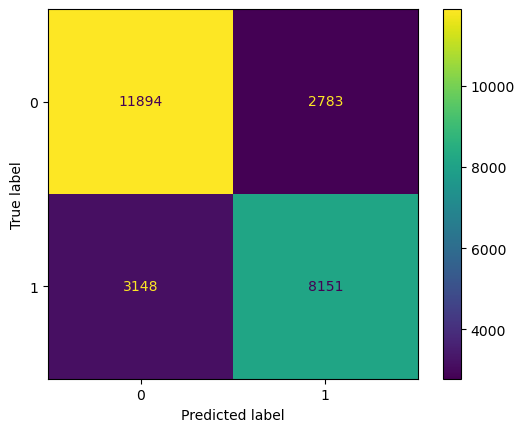

In [ ]:
#Random Forest metrics

print('Random Forest metrics using the importantest 4 variables according to T-test : \n')
cr_4 = classification_report(y_val, y_predict_4_rf )
print(f'classification report:\n {cr_4}')
cm_4 = ConfusionMatrixDisplay.from_predictions(y_val, y_predict_4_rf)
print(f'Confusion Matrix{cm_4}')

Adaboost metrics using the importantest 4 variables according to T-test : 

classification report:
               precision    recall  f1-score   support

           0       0.77      0.89      0.82     14677
           1       0.81      0.65      0.72     11299

    accuracy                           0.78     25976
   macro avg       0.79      0.77      0.77     25976
weighted avg       0.79      0.78      0.78     25976



Confusion Matrix<sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x0000027232872250>


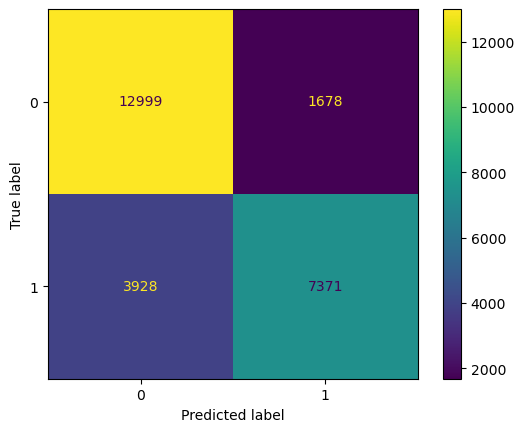

In [ ]:
#Adaboost  metrics

print('Adaboost metrics using the importantest 4 variables according to T-test : \n')
cr_ada = classification_report(y_val, y_predict_4_ada)
print(f'classification report:\n {cr_ada}')
cm_4 = ConfusionMatrixDisplay.from_predictions(y_val, y_predict_4_ada)
print(f'Confusion Matrix{cm_4}')

Gradientboost metrics using the importantest 4 variables according to T-test : 

classification report:
               precision    recall  f1-score   support

           0       0.77      0.89      0.82     14677
           1       0.81      0.65      0.72     11299

    accuracy                           0.78     25976
   macro avg       0.79      0.77      0.77     25976
weighted avg       0.79      0.78      0.78     25976

Confusion Matrix<sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x0000027232871F50>


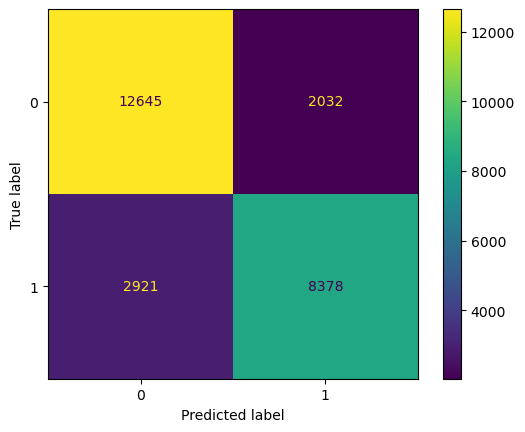

In [ ]:
#Gradient boosting metrics


print('Gradient boosting metrics using the importantest 4 variables according to T-test : \n')
cr_gb = classification_report(y_val, y_predict_4_gb)
print(f'classification report:\n {cr_gb}')
cm_4 = ConfusionMatrixDisplay.from_predictions(y_val, y_predict_4_gb)
print(f'Confusion Matrix{cm_4}')

# GridSearch Gradient Boosting (Road 2)

Now that we know Gradient Boosting is the best model on Road 2, we tune its hyperparameters using GridSearchCV. Grid Search exhaustively tries every combination of the specified parameters and uses 5-fold cross validation to evaluate each one.

In [ ]:
# Parameters explored:
param_grid_4 = {
    'n_estimators': [100, 200, 300], #number of sequential trees
    'learning_rate': [0.05, 0.1, 0.2], #step size at each iteration — lower means slower but more precise learning
    'subsample': [0.8, 1.0], # fraction of training samples used per tree, helps reduce overfitting
    'min_samples_leaf': [1, 2, 4] #minimum samples required at a leaf node, controls tree complexity
}

grid_4 = GridSearchCV(
    estimator=gb_4,  
    param_grid=param_grid_4,
    cv=5,
    scoring = 'accuracy',
    verbose = 1,
    n_jobs=-1
)

grid_4.fit(X_train_4, y_train)

print(f'Parametri migliori: {grid_4.best_params_}')
print(f'Accuracy migliore:  {grid_4.best_score_:.3f}')

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Parametri migliori: {'learning_rate': 0.2, 'min_samples_leaf': 4, 'n_estimators': 300, 'subsample': 0.8}
Accuracy migliore:  0.813


# Final evaluation of Gradient Boosting (Road 2) on the test set

Gradientboost metrics using the best parameters according to gridsearch and the 4 importantest variables according to T-test: 

classification report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84      8730
           1       0.82      0.75      0.78      6856

    accuracy                           0.82     15586
   macro avg       0.82      0.81      0.81     15586
weighted avg       0.82      0.82      0.82     15586

Confusion Matrix<sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002723A0A6E50>


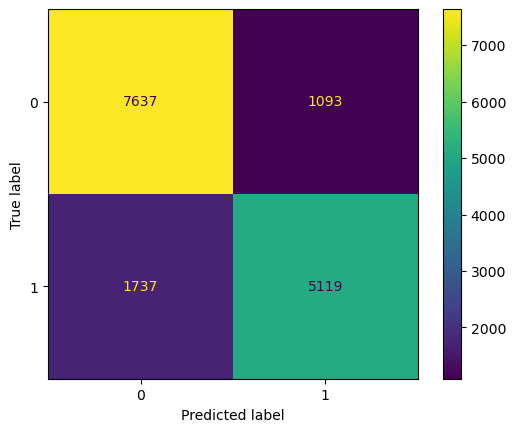

In [142]:
best_model_4 = grid_4.best_estimator_
y_pred_test_4 = best_model_4.predict(X_test_4)

print('Gradientboost metrics using the best parameters according to gridsearch and the 4 importantest variables according to T-test: \n')
cr_final_4_gb = classification_report(y_test, y_pred_test_4)
print(f'classification report:\n {cr_final_4_gb}')
cm_final_4_gb = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_4)
print(f'Confusion Matrix{cm_final_4_gb}')

# GridSearch Random Forest (Road 1)
Same process did for road 2

In [ ]:
#We use the full pipeline (preprocessor + model) inside GridSearchCV to prevent data leakage: the OrdinalEncoder fits only on each training fold, never on validation data.

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

param_grid = {
    'model__n_estimators': [100, 200, 300], # number of trees
    'model__max_depth': [None, 10, 20], # maximum depth per tree (None = unlimited
    'model__min_samples_split': [2, 5, 10], # minimum samples needed to split a node
    'model__min_samples_leaf': [1, 2, 4] # minimum samples required at a leaf
}

grid = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_model, y_train)

print(f'Parametri migliori: {grid.best_params_}')
print(f'Accuracy migliore:  {grid.best_score_:.3f}')

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Parametri migliori: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Accuracy migliore:  0.963


#  Final evaluation of Random Forest (Road 1) on the test set

We evaluate the best Random Forest on the test set.

This is the final comparison between Road 1 and Road 2: whichever model scores higher here is our overall best model.

Random Forest metrics using the best parameters according to gridsearch : 

classification report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      8730
           1       0.98      0.95      0.96      6856

    accuracy                           0.97     15586
   macro avg       0.97      0.97      0.97     15586
weighted avg       0.97      0.97      0.97     15586

Confusion Matrix<sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x00000272354C5250>


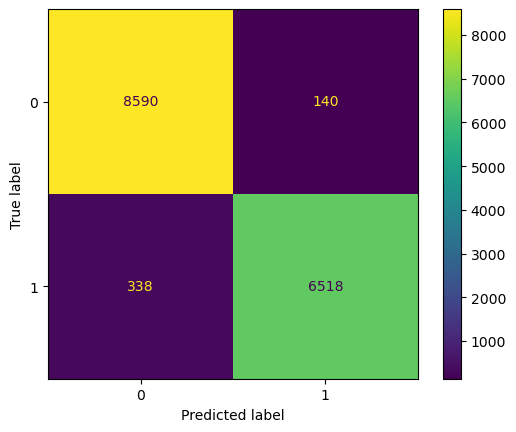

In [143]:
best_model = grid.best_estimator_
y_pred_test = best_model.predict(X_test_model)

print('Random Forest metrics using the best parameters according to gridsearch : \n')
cr_final_rf = classification_report(y_test, y_pred_test)
print(f'classification report:\n {cr_final_rf}')
cm_final_rf = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
print(f'Confusion Matrix{cm_final_rf}')

# Final Discussion

### The problem
The goal was to predict whether an airline passenger would be satisfied or not,
based on demographic information, flight type and service ratings.
This is a binary classification problem.

### EDA findings
Business class passengers are significantly more satisfied than Economy ones.
Passengers traveling for business purposes show higher satisfaction than leisure travelers.
In-flight wifi, entertainment and seat comfort are among the most correlated
features with overall satisfaction.

### Feature selection
Chi-square, Mutual Information and T-test produced fairly consistent results.
The 4 most discriminating numerical features according to the T-test are:
Age, Flight Distance, Inflight wifi service and Ease of Online booking.

### Road 1 vs Road 2
Road 1 (all features) outperforms Road 2 (4 features) — as expected,
more information helps. The tuned Random Forest on Road 1 reaches ~96% accuracy
on the test set. The tuned Gradient Boosting on Road 2 stays noticeably lower,
confirming that the discarded features carry meaningful predictive signal.

### Final model
The best model is the Random Forest with hyperparameters optimized via GridSearchCV,
trained on the full feature set (Road 1). It is robust, handles mixed data types
well and does not require feature scaling, making it practical to deploy.

### Possible improvements
- Try XGBoost or LightGBM, which often outperform standard Gradient Boosting
- Analyze Random Forest feature importances to understand which services
  drive satisfaction the most — useful actionable insight for the airline
- Explore SMOTE or class weighting strategies to better handle the class imbalance